In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import os
import re
import dask as da
from dask.diagnostics import ProgressBar
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.gpat import mc_test, boxm_test
from pycontrails.models.gpat.pp_gpat import GPATPostProcessor

In [2]:
outputs_dir = "/projects/Impact_of_aviation_on_climate/Kieran2024/outputs/" #

In [3]:
# Filter criteria
criteria = {
        # "n_ac": 3,
        # "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
        # "date_created": (pd.Timestamp("2024-11-16"), pd.Timestamp("2024-11-17")),
        "job_id": "id_vs_plume"
    }

In [4]:
pp_gpat = GPATPostProcessor(outputs_dir, criteria)
pp_gpat.filtered_df


,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,traj_gen_proc,gen_met_proc,bg_chem_proc,ac_perf_proc,emissions_proc,sim_plumes_proc,plume_to_grid_proc,run_cc_proc,run_boxm_proc,gen_outputs_proc
job_id,,,,,,,,,,,,,,,,,,,,,
id_vs_plume_NA_10_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",10,0 days 00:02:00,...,0.013753,5.363501,0.278070,0.180101,0.326307,3.255747,3118.299986,9.989999e-07,8.259106,0
id_vs_plume_NA_3_1000_0_ID_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",3,0 days 00:02:00,...,0.012012,5.375938,0.279309,0.061991,0.115117,0.878836,7.157876,1.092000e-06,8.239275,0
id_vs_plume_NA_1_1000_0_ID_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",1,0 days 00:02:00,...,0.016138,5.412613,0.283305,0.030330,0.064858,0.930789,7.167538,1.069000e-06,8.276019,0
id_vs_plume_NA_5_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",5,0 days 00:02:00,...,0.012687,5.371113,0.280896,0.097232,0.175053,2.010043,1585.215207,1.184000e-06,8.234905,0
id_vs_plume_NA_1_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",1,0 days 00:02:00,...,0.011706,5.388184,0.265193,0.030030,0.054520,1.010974,331.359741,1.224000e-06,8.265082,0
id_vs_plume_NA_5_1000_0_ID_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",5,0 days 00:02:00,...,0.012930,5.405015,0.279324,0.096945,0.174741,0.963366,7.142711,9.750000e-07,8.227780,0
id_vs_plume_NA_3_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",3,0 days 00:02:00,...,0.012012,5.375503,0.288927,0.062173,0.115115,1.498211,946.443330,1.032000e-06,8.234653,0
id_vs_plume_NA_2_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",2,0 days 00:02:00,...,0.012054,5.343743,0.279024,0.044582,0.083892,1.242340,639.481765,1.089000e-06,8.250915,0
id_vs_plume_NA_2_1000_0_ID_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",2,0 days 00:02:00,...,0.012263,5.390823,0.279916,0.044487,0.083618,0.834934,7.141137,1.156000e-06,8.240439,0


In [5]:
# Create dicts to hold all necessary data (but no more)
fl_df_dict = {}
pl_df_dict = {}

In [6]:
# Initialize the dictionary
chem_ds_dict = {}

# Load the data
for job_id in pp_gpat.job_ids:
    chem_ds_dict[job_id] = pp_gpat.load_chem_ds(job_id, 1000)




/user/home/kt16229/BOXM/scratch/miniconda3/envs/contrails/lib/python3.12/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Loaded chem ds for id_vs_plume_NA_10_1000_0_2_0.01_0.05
Loaded chem ds for id_vs_plume_NA_3_1000_0_ID_0.01_0.05
Loaded chem ds for id_vs_plume_NA_1_1000_0_ID_0.01_0.05
Loaded chem ds for id_vs_plume_NA_5_1000_0_2_0.01_0.05
Loaded chem ds for id_vs_plume_NA_1_1000_0_2_0.01_0.05
Loaded chem ds for id_vs_plume_NA_5_1000_0_ID_0.01_0.05
Loaded chem ds for id_vs_plume_NA_3_1000_0_2_0.01_0.05
Loaded chem ds for id_vs_plume_NA_2_1000_0_2_0.01_0.05
Loaded chem ds for id_vs_plume_NA_2_1000_0_ID_0.01_0.05
Loaded chem ds for id_vs_plume_NA_10_2000_0_2_0.05_0.05
Loaded chem ds for id_vs_plume_NA_10_1000_0_ID_0.01_0.05


KeyError: 'bg_run_NA_2022-09-01T12_00_00'

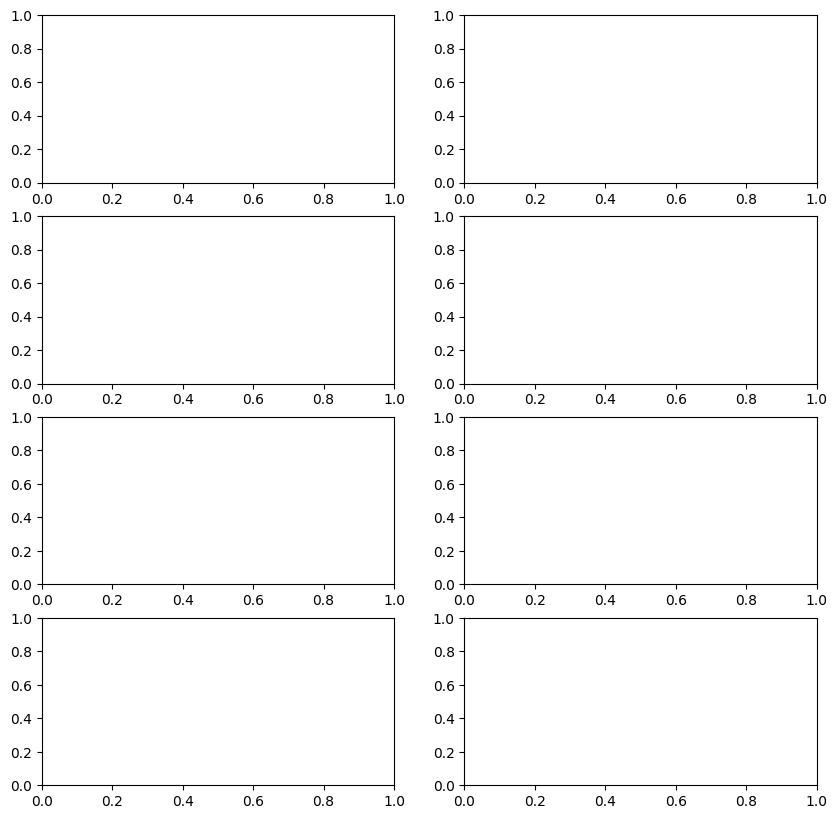

In [7]:
# bg run conc time series plots
fig, ax = plt.subplots(4, 2, figsize=(10, 10))

chem_ds = chem_ds_dict['bg_run_NA_2022-09-01T12_00_00']
chem_ds = pp_gpat.calc_cell(chem_ds, 1, 1)
chem_ds = chem_ds.isel(job_id=0)

# get time var
time = chem_ds["time"].values

# get month from time var
month = pd.to_datetime(time).month

# species to plot
NO = chem_ds["Y"].sel(species_out="NO").values
NO2 = chem_ds["Y"].sel(species_out="NO2").values
NOx = NO + NO2
O3 = chem_ds["Y"].sel(species_out="O3").values
OH = chem_ds["Y"].sel(species_out="OH").values
HO2 = chem_ds["Y"].sel(species_out="HO2").values
CO = chem_ds["Y"].sel(species_out="CO").values
CH4 = chem_ds["Y"].sel(species_out="CH4").values

NOy = pp_gpat.calc_NOy(chem_ds)
NOz = pp_gpat.calc_NOz(chem_ds)

NOPR = pp_gpat.calc_NOPR(chem_ds)
NO2t = pp_gpat.calc_NO2t(chem_ds)
O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz)
HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds)
alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds)

pp_gpat.plot_line_plot(ax[0, 0], time, NO, 'NO', 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[0, 1], time, NO2, 'NO2', 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[1, 0], time, O3, 'O3', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[1, 1], time, NOy, 'NOy', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[2, 0], time, OH, 'OH', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[2, 1], time, HO2, 'HO2', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[3, 0], time, CO, 'CO', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[3, 1], time, CH4, 'CH4', 'Time / days', 'Concentration / ppb')
ax[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
fig.suptitle('Time series of species concentrations for background run NA Jan')
plt.tight_layout()
plt.savefig(f"{outputs_dir}/plots/bg_run_NA_Jan_concs_time_series.png")
plt.show()

In [ ]:
if 10 == 20:    
# bg run metric time series plots
    fig, ax = plt.subplots(3, 2, figsize=(10, 7.5))

    # get time var
    time = chem_ds["time"].values

    # get month from time var
    month = pd.to_datetime(time).month

    # species to plot
    NO = chem_ds["Y"].sel(species_out="NO").values
    NO2 = chem_ds["Y"].sel(species_out="NO2").values
    NOx = NO + NO2
    O3 = chem_ds["Y"].sel(species_out="O3").values
    OH = chem_ds["Y"].sel(species_out="OH").values
    HO2 = chem_ds["Y"].sel(species_out="HO2").values
    CO = chem_ds["Y"].sel(species_out="CO").values
    CH4 = chem_ds["Y"].sel(species_out="CH4").values

    NOy = pp_gpat.calc_NOy(chem_ds)
    NOz = pp_gpat.calc_NOz(chem_ds)

    NOPR = pp_gpat.calc_NOPR(chem_ds)
    NO2t = pp_gpat.calc_NO2t(chem_ds)
    O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz)
    HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
    H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds)
    alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds) 

    pp_gpat.plot_line_plot(ax[0, 0], time, NOx, 'NOx', 'Time / days', 'Concentration / ppb')
    pp_gpat.plot_line_plot(ax[0, 1], time, NO2t, 'NO2 Threshold', 'Time / days', 'Concentration / ppb') 
    pp_gpat.plot_line_plot(ax[1, 0], time, O3_NOz, 'O3 / NOz', 'Time / days', '') 
    pp_gpat.plot_line_plot(ax[1, 1], time, HCHO_NO2, 'HCHO / NO2', 'Time / days', '')
    pp_gpat.plot_line_plot(ax[2, 0], time, H2O2_HNO3, 'H2O2 / HNO3', 'Time / days', '')
    pp_gpat.plot_line_plot(ax[2, 1], time, alpha_CH3O2, 'alpha CH3O2', 'Time / days', '')

    # ax[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
    fig.suptitle('Time series of NOx saturation metrics for background run NA Jan')
    plt.tight_layout()
    plt.savefig(f"{outputs_dir}/plots/bg_run_NA_Jan_metrics_time_series.png")
    plt.show()



In [ ]:
# chem_da = []
# emi_da = []
# # Create a figure and axis for plotting
# fig, ax = plt.subplots(figsize=(10, 6))

# for job, ds in enumerate(chem_ds):
#     chem_ds[job] = chem_ds[job].assign_coords(species_out=chem_ds[job].attrs["species_out"])
#     chem_da.append(chem_ds[job]["Y"])

#     emi_da.append(chem_ds[job]["emi"])

#     chem_da_cell = chem_da[job].sel(level=chem_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')
#     emi_da_cell = emi_da[job].sel(level=emi_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')

#     NO_data = chem_da_cell.sel(species_out="NO")
#     NO2_data = chem_da_cell.sel(species_out="NO2")
#     O3_data = chem_da_cell.sel(species_out="O3")

#     NO_emi_data = emi_da_cell.sel(emi_species="NO")
#     NO2_emi_data = emi_da_cell.sel(emi_species="NO2")

#     # Plot the time series data
#     #NO_data.plot(ax=ax, label=f"NO {chem_da_cell['job_id'].values[0]}")
#     NO_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")
#     NO_emi_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")

# # Add labels and legend
# ax.set_xlabel('Time')
# ax.set_ylabel('Concentration')
# ax.set_title('Time Series of Species Concentration at Selected Cell')
# ax.legend()

# # plt.show()
# pd.set_option('display.max_rows', 500)
# NO_df = NO_data.to_dataframe()
# NO_df

# NO_data.max()


In [ ]:

# chem_ds_stacked = chem_ds.stack(
#             {"cell": ["level", "longitude", "latitude"]}
#         )
# chem_ds_stacked = chem_ds_stacked.reset_index("cell")

# chem_ds_stacked
 

In [ ]:

# max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
# print(max_emi_cell)
# # find cell that has max emissions averaged over time in it
# cell_chem_ds = chem_ds_stacked.sel(job_id=job_ids[0], cell=max_emi_cell)
# cell_chem_ds
# # Select the emissions for the specified species
# emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# emi_data.plot()
# chem_data.plot()

# # # Convert time and emi data to pandas Series
# # ts = 0
# # time_series = pd.Series(emi_data["time"].values)
# # emi_series = pd.Series(emi_data.values)

# # # Print time and emi values side by side
# # for time, emi in zip(time_series, emi_series):
# #     ts += 1
# #     print(f"TS: {ts}, Time: {time}, EMI: {emi}")

# for s, species in enumerate(chem_ds["species"].values):
#     print(chem_ds["bg_chem"].isel(level=1,latitude=0,longitude=0, species=s).values)



In [ ]:
#anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds[0], var1="emi", var2="NO", level=chem_da[0].level[1], resample_freq="2min")

In [ ]:
# vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
# mc

In [ ]:
# path = '/user/work/kt16229/pycontrails_kt/pycontrails/models/gpat/'

# cell_chem_ds = boxm_test(path, job_ids[0], 0, chem_ds)

# # dj_data = cell_chem_ds["DJ"].sel(photol_coeffs=3)
# # dj_orig_data = cell_chem_ds["DJ_orig"].sel(photol_coeffs=3)
# # dj_data.plot()
# # dj_orig_data.plot()

# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# chem_orig_data = cell_chem_ds["Y_orig"].sel(species_out="NO")
# chem_data.plot()
# chem_orig_data.plot()
